# DressMe — Phase 3 walkthrough

**Data collection, EDA, label mapping, colour estimation, merge and splits**, in one place.

This notebook **does not re-run the pipeline**: it reads what the scripts in `src/` produced and explains it. The scripts stay the single source of truth, and [`reports/phase3_report.pdf`](../reports/phase3_report.pdf) is the formal report.

**Before running:** the datasets are not in git. Download them (see the README), then run the pipeline once from the project root:

```
map_*.py  →  estimate_colours.py  →  merge_and_split.py
```

The whole notebook then runs in about a minute.

| # | Section |
|---|---|
| 1 | Context and unified label schema |
| 2 | The three public datasets (EDA highlights) |
| 3 | Label mapping |
| 4 | Colour estimation and its real accuracy |
| 5 | Merged dataset and splits (validation EDA) |
| 6 | Outfits |
| 7 | Explore: traditional items |
| 8 | Limitations and next steps |

In [1]:
# Setup: paths, shared helpers from src/, DressMe chart style
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from plot_style import CMAP, DARK, GOLD, RUST, SERIES, apply  # noqa: E402

apply()
plt.rcParams["figure.dpi"] = 80          # small images keep the notebook light
pd.set_option("display.max_columns", 30)

DATA = ROOT / "data"
PROCESSED = DATA / "processed"
for f in ["dressme.csv", "colour_estimates.csv"]:
    if not (PROCESSED / f).exists():
        raise FileNotFoundError(f"{PROCESSED / f} is missing: run the pipeline first (see above)")


def read(path):
    # every CSV is read as text: empty cells stay "" (never NaN)
    return pd.read_csv(path, dtype=str, keep_default_na=False)


def picture(row, size=160):
    # one item as a small image; Fashionpedia items are cropped with their bbox
    img = Image.open(DATA / row["image_path"]).convert("RGB")
    if row.get("bbox_w", ""):
        x, y, w, h = (float(row[c]) for c in ["bbox_x", "bbox_y", "bbox_w", "bbox_h"])
        img = img.crop((x, y, x + w, y + h))
    img.thumbnail((size, size))
    return img


def show_grid(rows, title_of, ncols=8, size=1.6):
    # a grid of items, with a title under each
    rows = list(rows)
    nrows = max(1, -(-len(rows) // ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size * 1.25))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, row in zip(np.ravel(axes), rows):
        ax.imshow(picture(row))
        ax.set_title(title_of(row), fontsize=7)
    plt.tight_layout()
    plt.show()


print("Project root:", ROOT)

Project root: c:\dev\DressMe


## 1. Context and unified label schema

DressMe targets young Tunisians on a limited budget who shop mostly second-hand (*friperie*). The Phase 1 survey (57 responses) shaped the data choices:
- **black dominates 84% of wardrobes**, so the colour labels must separate black, navy and charcoal well;
- **56% shop second-hand**, so real friperie photos are kept for the test set;
- **40% are frustrated by fit**;
- **42% want “should I buy this?” advice**, so we need outfit compatibility data.

Every source is mapped to **one schema**: `category`, `sub_category`, `primary_colour` / `secondary_colour`, `pattern`, `season`, `usage`, `style`, `coverage` (1–5 modesty level) and `source`.

Rules:
- an unknown value stays **empty**: we never guess;
- multi-value fields use `|`;
- every rule lives in `mappings/*.csv`.

,allowed sub_category values
category,
accessory,"belt, bracelet, brooch, cap, cufflinks, earrin..."
bag,"backpack, clutch, duffel-bag, handbag, laptop-..."
bottom,"capris, jeans, leggings, shorts, skirt, track-..."
dress,"dress, jumpsuit"
outerwear,"blazer, cape, cardigan, coat, jacket, waistcoat"
shoes,"casual-shoes, flats, flip-flops, formal-shoes,..."
top,"shirt, sweater, sweatshirt, t-shirt, top, tunic"
traditional,"jebba, kaftan"


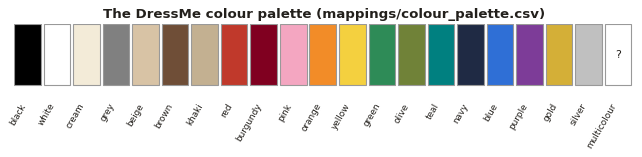

In [2]:
# The controlled vocabularies: sub-categories per category, and the 21-colour palette
vocab = read(ROOT / "mappings" / "sub_category_vocabulary.csv")
palette = read(ROOT / "mappings" / "colour_palette.csv")

display(vocab.groupby("category")["sub_category"]
        .agg(lambda s: ", ".join(sorted(s))).to_frame("allowed sub_category values"))

fig, ax = plt.subplots(figsize=(10, 1.2))
for i, (name, hexc) in enumerate(zip(palette["colour"], palette["hex"])):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=hexc or "#ffffff", ec="#999"))
    ax.text(i + 0.45, -0.25, name, rotation=60, ha="right", va="top", fontsize=8)
ax.text(len(palette) - 0.55, 0.5, "?", ha="center", va="center")  # multicolour has no single hex
ax.set_xlim(0, len(palette)); ax.set_ylim(-0.2, 1); ax.axis("off")
ax.set_title("The DressMe colour palette (mappings/colour_palette.csv)")
plt.show()

## 2. The three public datasets (EDA highlights)

Full EDA reports: [Fashion Product](../reports/eda_fashion_product.md) · [Fashionpedia](../reports/eda_fashionpedia.md) · [PolyVore](../reports/eda_polyvore.md). The charts below are the ones those scripts saved.

### Kaggle Fashion Product Images (Small)
44,441 catalogue shots of 60×80 px. It is the **only source with real labels** for colour, season, usage and gender.

Main issues:
- 142 article types, 72 of them with fewer than 50 images;
- 2,430 off-topic rows (personal care, home, sporting goods).

![article types](../reports/figures/fashion_product/articleType_top40.png)
![base colour](../reports/figures/fashion_product/baseColour.png)

### Fashionpedia
46,781 labelled street and runway photos with **several items per photo** (median 3), segmentation masks and 294 fine-grained attributes (pattern, length, nickname, silhouette).

Main issues:
- **no colour label**;
- shoes are labelled one per foot;
- 33.8% of item crops are shorter than 64 px.

![items](../reports/figures/fashionpedia/items.png)
![crop sizes](../reports/figures/fashionpedia/bbox_short_side.png)

### Maryland PolyVore (Re-PolyVore)
126,927 product shots on white, regrouped into **31,333 user-made outfits**: the main source for outfit compatibility.

Main issues:
- labels come from the folder name only;
- about 24k exact duplicate images, which must stay in one split.

![categories](../reports/figures/polyvore/categories.png)
![co-occurrence](../reports/figures/polyvore/cooccurrence.png)

In [3]:
# Size of each dataset after mapping (one row = one item)
sizes = {name: len(read(PROCESSED / f"{name}.csv"))
         for name in ["fashion_product", "fashionpedia", "polyvore"]}
pd.Series(sizes, name="rows after mapping").to_frame().assign(
    share=lambda d: (100 * d.iloc[:, 0] / d.iloc[:, 0].sum()).round(1).astype(str) + "%")

,rows after mapping,share
fashion_product,38081,11.8%
fashionpedia,160027,49.4%
polyvore,125910,38.9%


## 3. Label mapping

Each dataset has its own rules in `mappings/`:
- the apply script **stops** if a source value has no rule;
- rows whose note says `REVIEW` are open team decisions.

Example: how Fashion Product article types become DressMe categories.

In [4]:
art = read(ROOT / "mappings" / "fashion_product_articletype.csv")
display(art.sample(8, random_state=1))

# All open team decisions, across every mapping file
review = []
for f in sorted((ROOT / "mappings").glob("*.csv")):
    rules = read(f)
    for _, r in rules.iterrows():
        if any("REVIEW" in str(v) for v in r.values):
            review.append({"file": f.name, "rule": r.iloc[0], "note": r.get("note", "")})
display(Markdown(f"**{len(review)} open `REVIEW` decisions**"))
pd.DataFrame(review)

,articleType,keep,category,sub_category,note
89,Innerwear Vests,no,,,innerwear
44,Backpacks,yes,bag,backpack,
56,Belts,yes,accessory,belt,
81,Salwar and Dupatta,no,,,multi-item set in one photo
69,Dupatta,yes,accessory,scarf,Indian ethnic shawl
101,Wristbands,no,,,sport equipment
97,Socks,no,,,rarely visible in an outfit
58,Wallets,yes,accessory,wallet,


**11 open `REVIEW` decisions**

,file,rule,note
0,fashion_product_articletype.csv,Kurtas,Indian ethnic; looks like a long tunic. REVIEW
1,fashion_product_articletype.csv,Kurtis,Indian ethnic; looks like a long tunic. REVIEW
2,fashion_product_articletype.csv,Churidar,Indian ethnic fitted trousers. REVIEW
3,fashion_product_articletype.csv,Salwar,Indian ethnic loose trousers. REVIEW
4,fashion_product_articletype.csv,Patiala,Indian ethnic loose trousers. REVIEW
5,fashion_product_articletype.csv,Sarees,Indian ethnic with no Tunisian equivalent. REVIEW
6,fashion_product_articletype.csv,Swimwear,no swimwear category in schema. REVIEW
7,fashion_product_usage.csv,Ethnic,Indian festive wear; REVIEW: could be eid / we...
8,fashionpedia_category.csv,13,sunglasses and eyeglasses together. REVIEW: Ka...
9,fashionpedia_pattern.csv,herringbone (pattern),woven texture; REVIEW (could be solid)


**A decision taken:** a Fashionpedia *kaftan* now maps to `traditional`, because it is close to the Maghreb caftan. Nickname rules have an optional `category` column that allows this kind of move.

### Coverage (modesty level) from Fashionpedia
Neckline and sleeve-length attributes sit on *part* objects, not on the garment itself:
1. each sleeve or neckline is linked to the one upper garment whose box contains it;
2. the item's coverage is the **lowest** score among its length, nickname, sleeve and neckline (the most revealing part decides);
3. `coverage_from` records which of these sources were used.

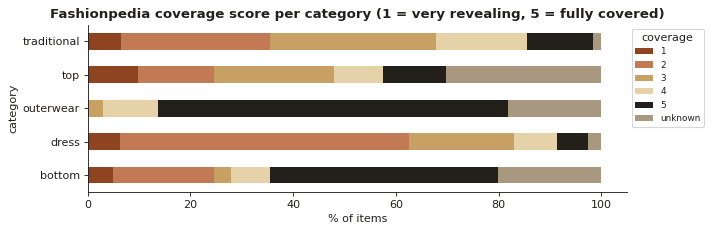

,items
coverage_from,
length,19784
sleeve,15389
(none),14567
length|neckline,7907
neckline|sleeve,6960
length|neckline|sleeve,4172
neckline|nickname,2635
nickname,2035


In [5]:
fpd = read(PROCESSED / "fashionpedia.csv")
clothes = fpd[fpd["category"].isin(["top", "bottom", "dress", "outerwear", "traditional"])]
cov = pd.crosstab(clothes["category"], clothes["coverage"].replace("", "unknown"))
ax = (cov.div(cov.sum(axis=1), axis=0) * 100).plot(
    kind="barh", stacked=True, figsize=(9, 3), color=[RUST, "#C27A55", GOLD, "#E6D2A8", DARK, "#A8987F"])
ax.set_xlabel("% of items"); ax.set_title("Fashionpedia coverage score per category (1 = very revealing, 5 = fully covered)")
ax.legend(title="coverage", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); plt.show()
clothes["coverage_from"].replace("", "(none)").value_counts().head(8).to_frame("items")

## 4. Colour estimation and its real accuracy

Only Fashion Product has colour labels. We first tried the simplest rule: snap the item's median pixel to the nearest palette colour. Tested against Fashion Product's real labels, it was right only **25–36%** of the time:
- black fabric photographs as dark blue-grey, so it became *navy*;
- white in shadow became *cream* or *silver*.

So `src/estimate_colours.py` **learns** the colours instead:
- **model:** gradient boosting on a Lab colour histogram of the item's pixels;
- **training data:** Fashion Product's train split;
- **cut:** the colour is kept only when the model's confidence is ≥ 0.6 (team decision).

To check it on the real target data, 400 random val / test items were **labelled by hand** without seeing the model's answer.

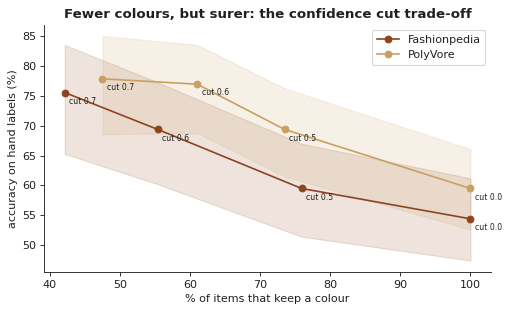

,dataset,cut,labelled,kept,coverage,accuracy,ci_low,ci_high
0,Fashionpedia,0.0,195,195,100.0,54.4,47.4,61.2
1,Fashionpedia,0.5,195,148,75.9,59.5,51.4,67.0
2,Fashionpedia,0.6,195,108,55.4,69.4,60.2,77.3
3,Fashionpedia,0.7,195,82,42.1,75.6,65.3,83.6
4,PolyVore,0.0,200,200,100.0,59.5,52.6,66.1
5,PolyVore,0.5,200,147,73.5,69.4,61.5,76.3
6,PolyVore,0.6,200,122,61.0,77.0,68.8,83.6
7,PolyVore,0.7,200,95,47.5,77.9,68.6,85.1


In [6]:
val = pd.read_csv(ROOT / "reports" / "colour_validation.csv")
fig, ax = plt.subplots(figsize=(6.5, 4))
for (name, g), colour in zip(val.groupby("dataset"), [RUST, GOLD]):
    ax.plot(g["coverage"], g["accuracy"], "o-", color=colour, label=name)
    ax.fill_between(g["coverage"], g["ci_low"], g["ci_high"], color=colour, alpha=0.15)
    for r in g.itertuples():
        ax.annotate(f"cut {r.cut}", (r.coverage, r.accuracy), fontsize=7,
                    xytext=(4, -10), textcoords="offset points")
ax.set_xlabel("% of items that keep a colour"); ax.set_ylabel("accuracy on hand labels (%)")
ax.set_title("Fewer colours, but surer: the confidence cut trade-off")
ax.legend(); plt.tight_layout(); plt.show()
val.round(1)

,mistakes (all confidences)
black → navy,19
black → brown,16
navy → blue,6
white → silver,5
burgundy → red,4
beige → brown,4
white → grey,4
blue → navy,4


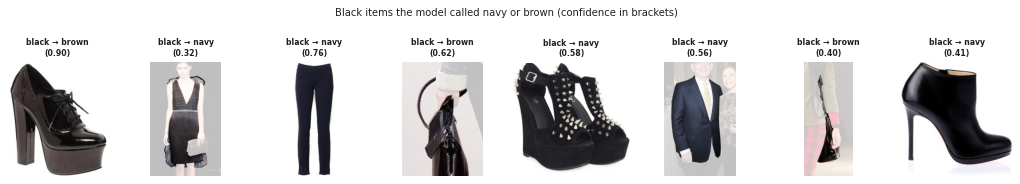

In [7]:
# Where does the model go wrong? Hand labels vs the model's best guess
labels = read(DATA / "interim" / "colour_labelling" / "colour_labels.csv")
est = read(PROCESSED / "colour_estimates.csv")
check = labels.merge(est, on="id")
check = check[~check["true_colour"].isin(["unsure", ""])]
wrong = check[check["true_colour"] != check["predicted_colour"]]
display((wrong["true_colour"] + " → " + wrong["predicted_colour"]).value_counts()
        .head(8).to_frame("mistakes (all confidences)"))

# The main error: black items read as navy or brown
black_errors = wrong[(wrong["true_colour"] == "black") & wrong["predicted_colour"].isin(["navy", "brown"])]
fig, axes = plt.subplots(1, 8, figsize=(13, 2.3))
for ax, r in zip(axes, black_errors.head(8).itertuples()):
    ax.imshow(Image.open(DATA / "interim" / "colour_labelling" / r.image_file))
    ax.set_title(f"black → {r.predicted_colour}\n({float(r.colour_confidence):.2f})", fontsize=7)
for ax in axes:
    ax.axis("off")
plt.suptitle("Black items the model called navy or brown (confidence in brackets)", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Merged dataset and splits (validation EDA)

`src/merge_and_split.py` writes `data/processed/dressme.csv`.

How the splits are made:
- **Ratio:** 80 / 10 / 10, decided by a hash of each group id, so the splits never change between runs.
- **`split` (classification):** per picture. All copies of a picture (`image_group`) share one split, and so do all items of a Fashionpedia photo.
- **`outfit_split` (compatibility):** per outfit.
- **Local photos** (`source` = wardrobe / friperie) always go to test.

In [8]:
df = read(PROCESSED / "dressme.csv")
df["duplicate"] = df["duplicate"] == "True"
uniq = df[~df["duplicate"]]
print(f"{len(df):,} rows, {len(uniq):,} unique pictures / crops, {df['duplicate'].sum():,} duplicate copies")
pd.crosstab(df["dataset"], df["split"], margins=True)[["train", "val", "test", "All"]]

324,018 rows, 299,514 unique pictures / crops, 24,504 duplicate copies


split,train,val,test,All
dataset,,,,
fashion_product,30441,3742,3898,38081
fashionpedia,128279,16102,15646,160027
polyvore,89720,17164,19026,125910
All,248440,37008,38570,324018


In [9]:
# The leak checks, re-run live: each must print True
checks = {
    "no picture is in two splits":
        (df.groupby("image_group")["split"].nunique() == 1).all(),
    "no outfit is in two outfit splits":
        (df[df["outfit_id"] != ""].groupby("outfit_id")["outfit_split"].nunique() == 1).all(),
    "every test outfit has only test pictures":
        (df.loc[df["outfit_split"] == "test", "split"] == "test").all(),
    "local photos are only in test":
        (df.loc[df["source"].isin(["wardrobe", "friperie"]), "split"] == "test").all(),
    "ids are unique":
        not df["id"].duplicated().any(),
}
pd.Series(checks, name="passed").to_frame()

,passed
no picture is in two splits,True
no outfit is in two outfit splits,True
every test outfit has only test pictures,True
local photos are only in test,True
ids are unique,True


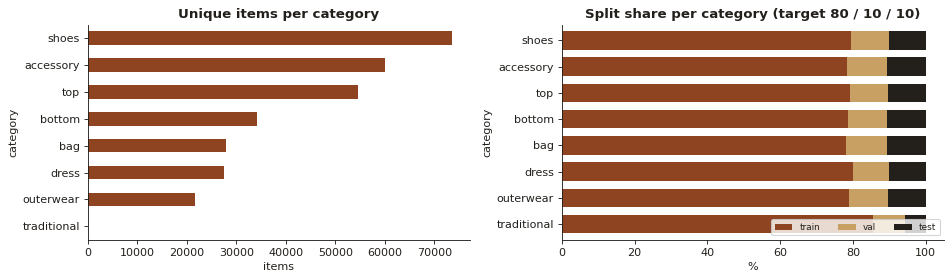

In [10]:
# Class balance: size of each category, and its share in each split
order = ["train", "val", "test"]
counts = uniq["category"].value_counts()
shares = pd.crosstab(uniq["category"], uniq["split"], normalize="index")[order] * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
counts.sort_values().plot.barh(ax=a1, color=RUST)
a1.set_title("Unique items per category"); a1.set_xlabel("items")
shares.loc[counts.index[::-1]].plot.barh(ax=a2, stacked=True, color=[RUST, GOLD, DARK], width=0.7)
a2.set_title("Split share per category (target 80 / 10 / 10)"); a2.set_xlabel("%")
a2.legend(ncol=3, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

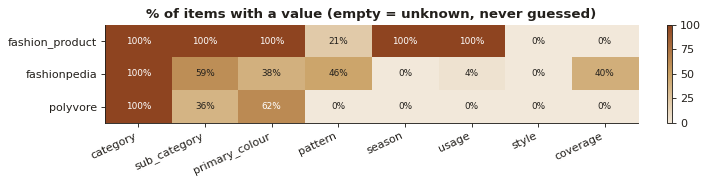

In [11]:
# Missing values: share of unique items with a value, per field and dataset
fields = ["category", "sub_category", "primary_colour", "pattern", "season", "usage", "style", "coverage"]
fill = pd.DataFrame({d: [(g[f] != "").mean() * 100 for f in fields] for d, g in uniq.groupby("dataset")},
                    index=fields).T
fig, ax = plt.subplots(figsize=(9, 2.4))
im = ax.imshow(fill.values, cmap=CMAP, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(fields)), fields, rotation=25, ha="right")
ax.set_yticks(range(len(fill)), fill.index)
for i in range(fill.shape[0]):
    for j in range(fill.shape[1]):
        ax.text(j, i, f"{fill.values[i, j]:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if fill.values[i, j] > 60 else DARK)
ax.set_title("% of items with a value (empty = unknown, never guessed)")
plt.colorbar(im, fraction=0.03); plt.tight_layout(); plt.show()

`style` is empty everywhere, and `season` / `usage` come almost only from Fashion Product. These fields will need model predictions or team annotation in Phase 4.

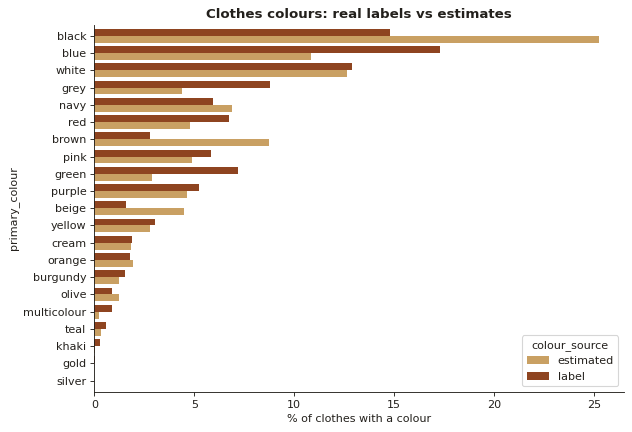

{'estimated': 'black = 25.2%', 'label': 'black = 14.8%'}


In [12]:
# Colour distribution of clothes: real labels vs estimates
cl = uniq[uniq["category"].isin(["top", "bottom", "dress", "outerwear"]) & (uniq["primary_colour"] != "")]
dist = pd.crosstab(cl["primary_colour"], cl["colour_source"], normalize="columns") * 100
dist = dist.loc[dist.sum(axis=1).sort_values().index]
ax = dist.plot.barh(figsize=(8, 5.5), color=[GOLD, RUST], width=0.8)
ax.set_xlabel("% of clothes with a colour"); ax.set_title("Clothes colours: real labels vs estimates")
plt.tight_layout(); plt.show()
print({src: f"black = {dist.loc['black', src]:.1f}%" for src in dist.columns})

The survey says black **dominates 84% of wardrobes**. That is a share of wardrobes, not of items, so it can't be compared directly with these percentages. The local photos (test set) will show how far the public data are from our users' real wardrobes.

## 6. Outfits

In PolyVore the same product is reused in many outfits, and those outfits share other products. As a result, **61% of PolyVore rows form one long chain**, and outfits and pictures cannot both be kept apart.

The rule we use:
- a picture used in a test outfit goes to test, so every test outfit is made only of test pictures;
- `outfit_clean` = False flags outfits that share a picture with another split;
- for a strict evaluation, use only the clean val / test outfits.

outfit_clean               clean  shares a picture
dataset      outfit_split                         
fashionpedia test           4575                 0
             train         37487                 0
             val            4681                 0
polyvore     test           1064              2013
             train         16674              8345
             val            1090              2128

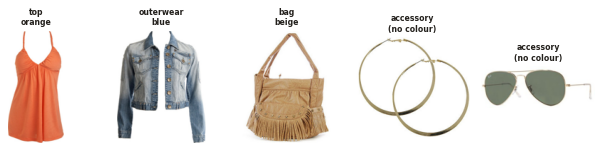

In [13]:
o = df[df["outfit_id"] != ""].drop_duplicates("outfit_id")
display(pd.crosstab([o["dataset"], o["outfit_split"]], o["outfit_clean"].map({"True": "clean", "False": "shares a picture"})))

# One clean PolyVore test outfit, item by item
pv = df[df["dataset"] == "polyvore"]
outfit_id = pv[(pv["outfit_split"] == "test") & (pv["outfit_clean"] == "True")]["outfit_id"].iloc[3]
items = pv[pv["outfit_id"] == outfit_id].sort_values("position")
show_grid(items.to_dict("records"), lambda r: f"{r['category']}\n{r['primary_colour'] or '(no colour)'}",
          ncols=len(items))

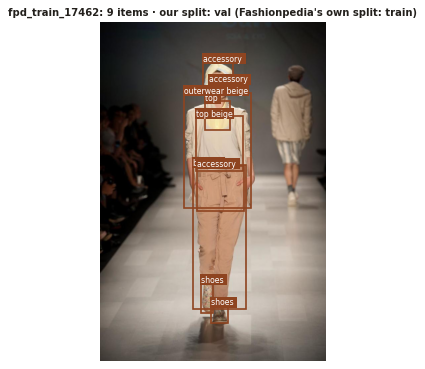

In [14]:
# One Fashionpedia photo = one outfit: every item with its box
photo = df[(df["dataset"] == "fashionpedia") & (df["split"] == "val")]
photo = photo[photo["outfit_id"] == photo["outfit_id"].value_counts().index[10]]
img = Image.open(DATA / photo["image_path"].iloc[0]).convert("RGB")
fig, ax = plt.subplots(figsize=(4, 5.5))
ax.imshow(img); ax.axis("off")
for r in photo.itertuples():
    x, y, w, h = (float(v) for v in (r.bbox_x, r.bbox_y, r.bbox_w, r.bbox_h))
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, ec=RUST, lw=1.5))
    ax.text(x, y, f"{r.category} {r.primary_colour}", color="white", fontsize=7,
            bbox=dict(facecolor=RUST, pad=1, lw=0))
plt.title(f"{photo['outfit_id'].iloc[0]}: {len(photo)} items · "
          f"our split: val (Fashionpedia's own split: {photo['original_split'].iloc[0]})", fontsize=9)
plt.show()

## 7. Explore: traditional items

The only public `traditional` items are the 124 Fashionpedia kaftans. Jebba, sefsari and other local garments must come from the **local photo collection**.

{'kaftan': 124} | split: {'train': 106, 'val': 11, 'test': 7}


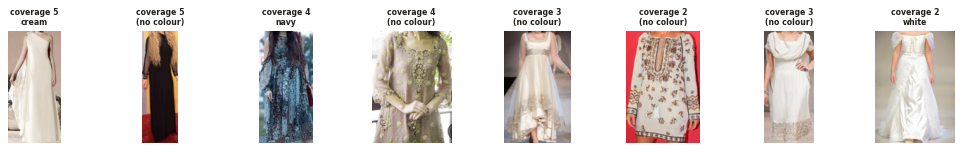

In [15]:
trad = df[df["category"] == "traditional"]
print(trad["sub_category"].value_counts().to_dict(), "| split:", trad["split"].value_counts().to_dict())
show_grid(trad.sample(8, random_state=3).to_dict("records"),
          lambda r: f"coverage {r['coverage'] or '?'}\n{r['primary_colour'] or '(no colour)'}")

## 8. Limitations and next steps

**Limitations**
- **Domain gap:** public images are catalogue or street shots, not friperie phone photos.
- **Missing labels:** no public `traditional` items besides kaftans, and no `style` labels.
- **Noisy colours:** estimated colours are 77% accurate on PolyVore and 69% on Fashionpedia, and black is often read as navy or brown.
- **Imbalance:** shoes and accessories dominate, while dress and outerwear are the smallest clothing classes.

**Next steps**
1. **Local collection:** wardrobes (500–1,000 items), friperie (150–300), local garments (50–100), a fit-check subset, and near-duplicate pairs. It needs signed consent and blurred faces.
2. **Open decisions:** settle the remaining `REVIEW` rules, then re-run the pipeline.
3. **Phase 4:**
   - train EfficientNet on `split` (without duplicates);
   - compute FashionCLIP embeddings;
   - fit the compatibility formula on `outfit_split`;
   - try a colour model on the embeddings to fix the black / navy confusion.